# Classical SVM and QSVM Comparison

## Objective

The goal of this project is to compare a classical SVM with quantum support vector machines using PennyLane and Qiskit.

The models will be tested on PneumoniaMNIST and BloodMNIST using the same samples, PCA-reduced features, and train-test splits.

We will begin with PneumoniaMNIST.

In [1]:
!pip install medmnist pennylane qiskit qiskit-aer qiskit-machine-learning


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
import medmnist

from medmnist import INFO
from medmnist import PneumoniaMNIST, BloodMNIST

from sklearn.decomposition import PCA
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

In [3]:
seed = 42
np.random.seed(seed)

## PneumoniaMNIST

PneumoniaMNIST is a binary image-classification dataset containing normal and pneumonia chest X-ray images.

We first load the original training, validation, and test splits.

In [4]:
data_flag = "pneumoniamnist"
info = INFO[data_flag]

PneumoniaData = getattr(medmnist, info["python_class"])

train_data = PneumoniaData(split="train", download=True)
val_data = PneumoniaData(split="val", download=True)
test_data = PneumoniaData(split="test", download=True)

In [5]:
x_train = train_data.imgs
y_train = train_data.labels.flatten()

x_val = val_data.imgs
y_val = val_data.labels.flatten()

x_test = test_data.imgs
y_test = test_data.labels.flatten()

print("Training:", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

print("Classes:", info["label"])

Training: (4708, 28, 28) (4708,)
Validation: (524, 28, 28) (524,)
Test: (624, 28, 28) (624,)
Classes: {'0': 'normal', '1': 'pneumonia'}


## Data preparation

The images are flattened into feature vectors. A balanced subset is selected to keep the quantum-kernel calculation manageable.

PCA reduces each image to four features, matching the four qubits that will be used later. The reduced features are then scaled using the training data.

In [7]:
x_tr_full = np.concatenate((x_train, x_val))
y_tr_full = np.concatenate((y_train, y_val))

print(x_tr_full.shape)
print(y_tr_full.shape)

(5232, 28, 28)
(5232,)


In [8]:
def balanced_subset(x, y, samples_per_class, seed=42):
    rng = np.random.default_rng(seed)

    selected = []

    for label in np.unique(y):
        indices = np.where(y == label)[0]
        selected.extend(rng.choice(
            indices,
            size=samples_per_class,
            replace=False
        ))

    selected = np.array(selected)
    rng.shuffle(selected)

    return x[selected], y[selected]

In [9]:
x_tr, y_tr = balanced_subset(
    x_tr_full,
    y_tr_full,
    samples_per_class=100,
    seed=seed
)

x_test, y_test = balanced_subset(
    x_test,
    y_test,
    samples_per_class=50,
    seed=seed
)

print("Training:", x_tr.shape, y_tr.shape)
print("Test:", x_test.shape, y_test.shape)

Training: (200, 28, 28) (200,)
Test: (100, 28, 28) (100,)


In [10]:
x_tr = x_tr.reshape(x_tr.shape[0], -1).astype(float) / 255.0
x_test = x_test.reshape(x_test.shape[0], -1).astype(float) / 255.0

print("Training:", x_tr.shape)
print("Test:", x_test.shape)

Training: (200, 784)
Test: (100, 784)


In [11]:
pca = PCA(n_components=4)

xs_tr = pca.fit_transform(x_tr)
xs_test = pca.transform(x_test)

print("Training:", xs_tr.shape)
print("Test:", xs_test.shape)
print("Explained variance:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Training: (200, 4)
Test: (100, 4)
Explained variance: [0.32580885 0.1226308  0.06611194 0.05991815]
Total explained variance: 0.5744697427561523


In [12]:
print("Training classes:", np.unique(y_tr, return_counts=True))
print("Test classes:", np.unique(y_test, return_counts=True))

Training classes: (array([0, 1], dtype=uint8), array([100, 100]))
Test classes: (array([0, 1], dtype=uint8), array([50, 50]))


## Classical SVM

A classical SVM with an RBF kernel is trained as the baseline. It uses the same PCA-reduced training and test data that will later be used by the quantum SVM.

In [13]:
start = time.time()

classical_svm = SVC(kernel="rbf")
classical_svm.fit(xs_tr, y_tr)

classical_time = time.time() - start

In [14]:
classical_predictions = classical_svm.predict(xs_test)

In [15]:
classical_accuracy = accuracy_score(y_test, classical_predictions)

print("Accuracy:", classical_accuracy)
print("Training time:", classical_time)

Accuracy: 0.84
Training time: 0.007110595703125


In [16]:
classical_confusion = confusion_matrix(
    y_true=y_test,
    y_pred=classical_predictions
)

print(classical_confusion)

[[38 12]
 [ 4 46]]


In [17]:
print(classification_report(
    y_true=y_test,
    y_pred=classical_predictions
))

              precision    recall  f1-score   support

           0       0.90      0.76      0.83        50
           1       0.79      0.92      0.85        50

    accuracy                           0.84       100
   macro avg       0.85      0.84      0.84       100
weighted avg       0.85      0.84      0.84       100



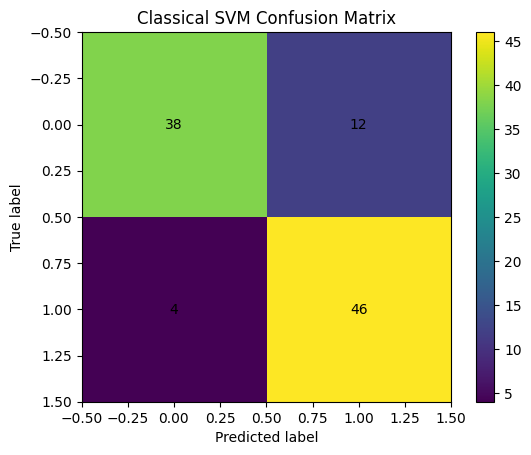

In [18]:
plt.imshow(classical_confusion)
plt.title("Classical SVM Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()

for i in range(classical_confusion.shape[0]):
    for j in range(classical_confusion.shape[1]):
        plt.text(
            j,
            i,
            classical_confusion[i, j],
            ha="center",
            va="center"
        )

plt.show()

## PennyLane Quantum SVM

The quantum SVM uses an angle-embedding fidelity kernel. Each sample is encoded into a four-qubit circuit, and the similarity between two samples is measured using the probability of returning to the all-zero state.

In [19]:
nqubits = 4
dev = qml.device("lightning.qubit", wires=nqubits)

@qml.qnode(dev)
def kernel_circ(a, b):
    qml.AngleEmbedding(a, wires=range(nqubits))
    qml.adjoint(qml.AngleEmbedding)(b, wires=range(nqubits))
    return qml.probs(wires=range(nqubits))

In [20]:
print(kernel_circ(xs_tr[0], xs_tr[0])[0])
print(kernel_circ(xs_tr[0], xs_tr[1])[0])

0.9999999999999996
0.7184140186558386


In [21]:
def qkernel(A, B):
    return np.array([
        [kernel_circ(a, b)[0] for b in B]
        for a in A
    ])

In [22]:
start = time.time()

quantum_svm = SVC(kernel=qkernel).fit(xs_tr, y_tr)

quantum_time = time.time() - start

In [23]:
quantum_predictions = quantum_svm.predict(xs_test)

In [24]:
quantum_accuracy = accuracy_score(y_test, quantum_predictions)

print("Accuracy:", quantum_accuracy)
print("Training time:", quantum_time)

Accuracy: 0.81
Training time: 63.761621952056885


In [25]:
quantum_confusion = confusion_matrix(
    y_true=y_test,
    y_pred=quantum_predictions
)

print(quantum_confusion)
print(classification_report(
    y_true=y_test,
    y_pred=quantum_predictions
))

[[38 12]
 [ 7 43]]
              precision    recall  f1-score   support

           0       0.84      0.76      0.80        50
           1       0.78      0.86      0.82        50

    accuracy                           0.81       100
   macro avg       0.81      0.81      0.81       100
weighted avg       0.81      0.81      0.81       100



In [26]:
print("Classical SVM accuracy:", classical_accuracy)
print("Quantum SVM accuracy:", quantum_accuracy)

print("Classical SVM training time:", classical_time)
print("Quantum SVM training time:", quantum_time)

Classical SVM accuracy: 0.84
Quantum SVM accuracy: 0.81
Classical SVM training time: 0.007110595703125
Quantum SVM training time: 63.761621952056885
